```{contents}
```


## Intiution

An **autoencoder** is a neural network that learns to **recreate its input**.
It doesn’t need labels — it’s **unsupervised learning**.

Its goal:

> Compress data → then reconstruct it as accurately as possible.

---

### **Architecture**

It has two parts:

```
Input → Encoder → Latent Space → Decoder → Output
```

| Part                 | Purpose                                                              |
| -------------------- | -------------------------------------------------------------------- |
| **Encoder**          | Compresses input data into a smaller vector (latent representation). |
| **Latent space (z)** | Captures essential information in fewer dimensions.                  |
| **Decoder**          | Reconstructs the input from the compressed latent vector.            |

---

### **Intuition**

Think of a **zip file** analogy:

* The **encoder** acts like `zip` → compresses the file to a smaller size.
* The **decoder** acts like `unzip` → tries to rebuild the original file.

The network is forced to **learn what is most important** in the data, since the bottleneck (latent space) restricts capacity.
→ This forces it to **capture the underlying structure** rather than memorizing pixel-by-pixel details.

---

### **Mathematical Workflow**

1. Input $x$
2. Encoder compresses:
   $$
   z = f_\theta(x)
   $$
   where $z$ = latent vector.
3. Decoder reconstructs:
   $$
   \hat{x} = g_\phi(z)
   $$
4. Training objective minimizes **reconstruction loss**:
   $$
   L = ||x - \hat{x}||^2
   $$
   or sometimes cross-entropy.

---

### **Why It Works**

By minimizing the difference between input and output,
the model learns a compact **internal representation** that contains the most meaningful information about the input distribution.

This is useful because:

* Redundant/noisy information is removed.
* The latent representation generalizes across similar inputs.

---

### **Intuitive Example**

Imagine feeding the network handwritten digits (MNIST):

* The **encoder** learns that “6” and “9” differ mainly by rotation.
* In latent space, similar digits lie close together.
* The **decoder** learns how to reconstruct those digits.

---

### **Applications**

| Use Case                     | Explanation                                       |
| ---------------------------- | ------------------------------------------------- |
| **Dimensionality reduction** | Like PCA but nonlinear.                           |
| **Denoising**                | Train to reconstruct clean data from noisy input. |
| **Anomaly detection**        | Unusual inputs → high reconstruction error.       |
| **Image compression**        | Compact latent representation.                    |
| **Pretraining**              | Encoder weights help initialize other models.     |

---

### **Visual Intuition**

```
[784 Inputs]
 ↓
[256 Neurons]
 ↓
[64 Neurons]   ← Bottleneck (Latent Representation)
 ↓
[256 Neurons]
 ↓
[784 Outputs]
```

* The bottleneck acts as a **filter**.
* The network must learn how to represent the input **efficiently**.

---

**In short:**

> Autoencoders **teach themselves** to understand what features of data matter most — by trying to **rebuild** what they just saw, using **fewer numbers** to describe it.

---

Would you like a **visual latent space example** (e.g., how digits cluster in 2D using an autoencoder)?


Creating synthetic dataset...
Using device: cpu
Using device: cpu
Starting training...
Starting training...
Epoch 1/10, Average Loss: 0.1228
Epoch 2/10, Average Loss: 0.0645
Epoch 1/10, Average Loss: 0.1228
Epoch 2/10, Average Loss: 0.0645
Epoch 3/10, Average Loss: 0.0513
Epoch 3/10, Average Loss: 0.0513
Epoch 4/10, Average Loss: 0.0425
Epoch 4/10, Average Loss: 0.0425
Epoch 5/10, Average Loss: 0.0346
Epoch 5/10, Average Loss: 0.0346
Epoch 6/10, Average Loss: 0.0298
Epoch 6/10, Average Loss: 0.0298
Epoch 7/10, Average Loss: 0.0262
Epoch 7/10, Average Loss: 0.0262
Epoch 8/10, Average Loss: 0.0246
Epoch 8/10, Average Loss: 0.0246
Epoch 9/10, Average Loss: 0.0228
Epoch 9/10, Average Loss: 0.0228
Epoch 10/10, Average Loss: 0.0217
Generating latent space visualization...
Epoch 10/10, Average Loss: 0.0217
Generating latent space visualization...


C:\Users\sangouda\AppData\Local\Temp\ipykernel_63448\140626826.py:140: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([], [], c=plt.cm.tab10(i/9), label=f'Digit {i}', s=50)


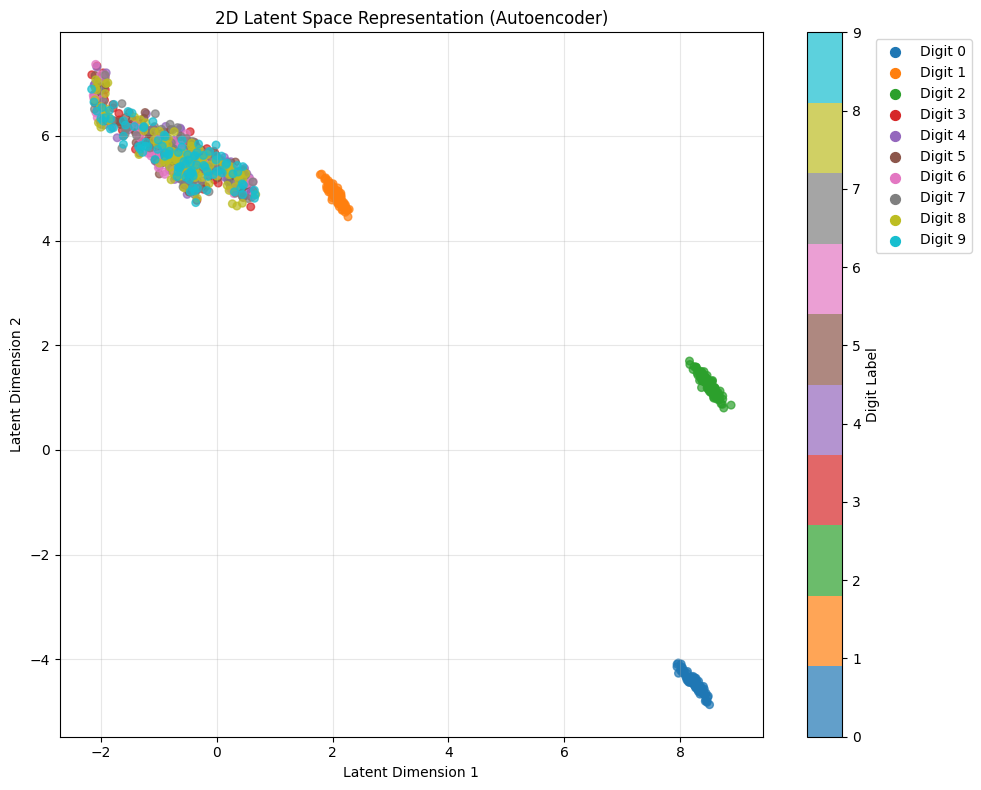

Visualizing reconstructions...


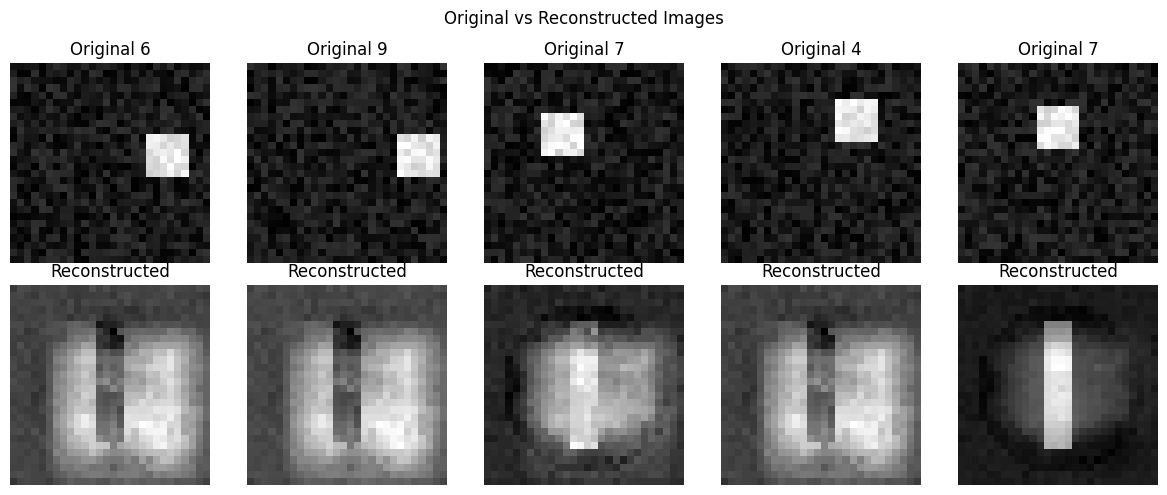

Autoencoder training and visualization completed!


In [1]:
# Alternative approach to avoid torchvision import issues
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

# Create synthetic MNIST-like data to avoid torchvision dependency
def create_synthetic_mnist_data(n_samples=1000):
    """Create synthetic digit-like data patterns"""
    np.random.seed(42)
    data = []
    labels = []
    
    for digit in range(10):
        for _ in range(n_samples // 10):
            # Create simple patterns for each digit
            img = np.random.rand(28, 28) * 0.2  # background noise
            
            # Add digit-specific patterns
            if digit == 0:  # Circle
                center = (14, 14)
                for i in range(28):
                    for j in range(28):
                        dist = ((i-center[0])**2 + (j-center[1])**2)**0.5
                        if 8 < dist < 12:
                            img[i, j] = 0.8 + np.random.rand() * 0.2
            elif digit == 1:  # Vertical line
                img[5:23, 12:16] = 0.8 + np.random.rand(18, 4) * 0.2
            elif digit == 2:  # Horizontal lines
                img[8:12, 4:24] = 0.8 + np.random.rand(4, 20) * 0.2
                img[15:19, 4:24] = 0.8 + np.random.rand(4, 20) * 0.2
            # Add more patterns for other digits...
            else:  # Random pattern for other digits
                x, y = np.random.randint(5, 23, 2)
                img[x:x+6, y:y+6] = 0.8 + np.random.rand(6, 6) * 0.2
            
            data.append(img.flatten())
            labels.append(digit)
    
    return np.array(data, dtype=np.float32), np.array(labels)

# --------------------------
# 1. Define a simple Autoencoder
# --------------------------
class Autoencoder2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)  # <-- 2D latent space
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out, z

# --------------------------
# 2. Create synthetic dataset
# --------------------------
print("Creating synthetic dataset...")
train_data, train_labels = create_synthetic_mnist_data(5000)
test_data, test_labels = create_synthetic_mnist_data(1000)

# Convert to tensors
train_tensor = torch.tensor(train_data)
test_tensor = torch.tensor(test_data)
test_labels_tensor = torch.tensor(test_labels)

# Create data loader
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# --------------------------
# 3. Initialize model, loss, optimizer
# --------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = Autoencoder2D().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# --------------------------
# 4. Train for a few epochs
# --------------------------
print("Starting training...")
for epoch in range(10):
    total_loss = 0
    for batch_idx, (x,) in enumerate(train_loader):
        x = x.to(device)
        output, _ = model(x)
        loss = criterion(output, x)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/10, Average Loss: {avg_loss:.4f}")

# --------------------------
# 5. Visualize latent space
# --------------------------
print("Generating latent space visualization...")
model.eval()
with torch.no_grad():
    test_tensor_device = test_tensor.to(device)
    _, z = model(test_tensor_device)

z = z.cpu().numpy()

# Create the plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(z[:, 0], z[:, 1], c=test_labels, cmap='tab10', s=30, alpha=0.7)
plt.colorbar(scatter, label='Digit Label')
plt.title("2D Latent Space Representation (Autoencoder)")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.grid(True, alpha=0.3)

# Add digit labels as legend
for i in range(10):
    mask = test_labels == i
    if np.any(mask):
        plt.scatter([], [], c=plt.cm.tab10(i/9), label=f'Digit {i}', s=50)
plt.legend(bbox_to_anchor=(1.15, 1), loc='upper left')

plt.tight_layout()
plt.show()

# --------------------------
# 6. Visualize some reconstructions
# --------------------------
print("Visualizing reconstructions...")
with torch.no_grad():
    sample_indices = np.random.choice(len(test_data), 5, replace=False)
    sample_data = test_tensor[sample_indices].to(device)
    reconstructed, _ = model(sample_data)
    
    sample_data = sample_data.cpu().numpy()
    reconstructed = reconstructed.cpu().numpy()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    # Original
    axes[0, i].imshow(sample_data[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title(f'Original {test_labels[sample_indices[i]]}')
    axes[0, i].axis('off')
    
    # Reconstructed
    axes[1, i].imshow(reconstructed[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title('Reconstructed')
    axes[1, i].axis('off')

plt.suptitle('Original vs Reconstructed Images')
plt.tight_layout()
plt.show()

print("Autoencoder training and visualization completed!")